Problem
Build a Linear Regression system that predicts salary based on experience, education, skills, and
location.
Requirements
Participants must:
1. Find dataset.
2. Perform feature engineering.
3. Handle categorical features.
4. Detect multicollinearity.
5. Train models.
6. Evaluate using:
• MAE
• MSE
• RMSE
• R²
Final Deliverables
• Jupyter Notebook
• visualizations
• detailed explanation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("salary_data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [4]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [6]:
# Numerical
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Years of Experience"] = df["Years of Experience"].fillna(df["Years of Experience"].mean())
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

# Categorical
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Education Level"] = df["Education Level"].fillna(df["Education Level"].mode()[0])
df["Job Title"] = df["Job Title"].fillna(df["Job Title"].mode()[0])

In [7]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Education Level"] = le.fit_transform(df["Education Level"])
df["Job Title"] = le.fit_transform(df["Job Title"])

In [8]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [9]:
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

               Feature        VIF
0                  Age  13.686738
1               Gender   2.285499
2      Education Level   4.315309
3            Job Title   3.750434
4  Years of Experience   6.164211


In [11]:
X = X.drop("Age", axis=1)

In [12]:
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

               Feature       VIF
0               Gender  1.945398
1      Education Level  3.601952
2            Job Title  2.550572
3  Years of Experience  3.976414


In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 24015.143901101244
MSE: 914371721.6123198
RMSE: 30238.580019774734
R2 Score: 0.6576271235195938


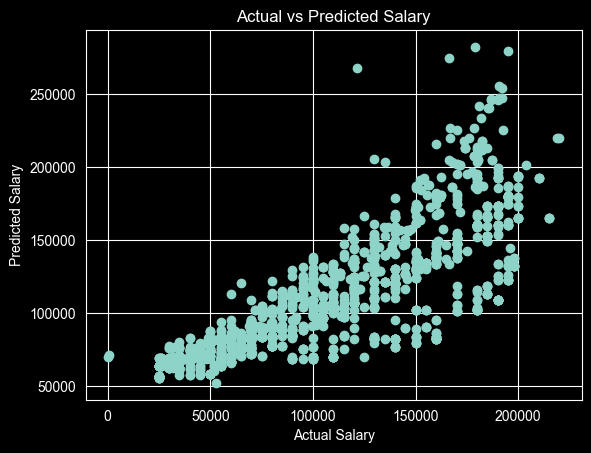

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

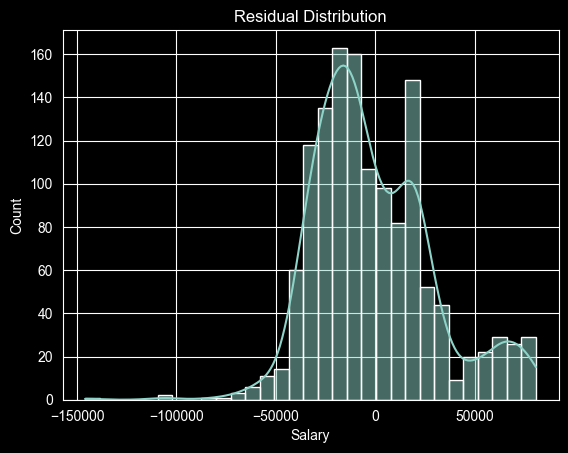

In [18]:
import seaborn as sns

residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

The Linear Regression model achieved an R² score of 0.65, indicating that approximately 65% of the variation in salary is explained by the features. The RMSE value of around 30,000 suggests moderate prediction error. After removing the "Age" feature due to high multicollinearity, the model became more stable and interpretable. However, there is still scope for improvement using advanced techniques.